In [1]:
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


# Load Data

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import xgboost as xgb
from helper import *
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
set_seed(42)
merged_building_df = pd.read_csv('/home/theo/Desktop/CESI_DUTh/XAI_Energy_Consumption_Prediction/Data/merged_sud_with_power.csv')

metric_datasets = extract_metric_datasets(merged_building_df)
co2_df = metric_datasets.get('CO2 indoor')
humidity_df = metric_datasets.get('HUM indoor')
temp_df = metric_datasets.get('TMP indoor')

df = merged_building_df

In [ ]:
df.head()

,Date and Time,TMP indoor t07,HUM indoor t07,CO2 indoor t07,VOCT indoor t07,DBAA indoor t07,DBAP indoor t07,LIGHT_LUX indoor t07,OCCUPANCY_RATE indoor t07,TMP indoor mediterranee_tribord,...,CO2 indoor pacifique_tribord,VOCT indoor pacifique_tribord,DBAA indoor pacifique_tribord,DBAP indoor pacifique_tribord,LIGHT_LUX indoor pacifique_tribord,OCCUPANCY_RATE indoor pacifique_tribord,Horodatage_Début,Valeur,Consommation,Horodatage_Fin
0,2026-03-01 00:00:00,16.0,57.0,264.0,17.0,37.0,44.0,0.0,0.0,17.2,...,127.0,15.0,36.0,40.0,0.0,0.0,2026-03-01 00:00:00,2.0,0.166667,2026-03-01 00:10:00
1,2026-03-01 00:10:00,16.0,56.0,272.0,30.0,37.0,48.0,0.0,0.0,17.2,...,108.0,15.0,37.0,42.0,0.0,0.0,2026-03-01 00:10:00,3.0,0.250000,2026-03-01 00:20:00
2,2026-03-01 00:20:00,15.9,56.0,263.0,31.0,38.0,47.0,0.0,0.0,17.2,...,124.0,16.0,37.0,44.0,5.0,0.0,2026-03-01 00:20:00,3.0,0.250000,2026-03-01 00:30:00
3,2026-03-01 00:30:00,15.9,56.0,274.0,23.0,38.0,50.0,0.0,0.0,17.2,...,115.0,16.0,37.0,44.0,0.0,0.0,2026-03-01 00:30:00,3.0,0.250000,2026-03-01 00:40:00
4,2026-03-01 00:40:00,15.9,56.0,279.0,25.0,38.0,50.0,0.0,0.0,17.2,...,111.0,16.0,37.0,41.0,0.0,0.0,2026-03-01 00:40:00,2.0,0.166667,2026-03-01 00:50:00


# Build flattened train/val/test arrays

In [ ]:

# ---------------------------------------------------------
# 2. Clean & scale
# ---------------------------------------------------------
cols_to_drop = ['Date and Time', 'Horodatage_Début', 'Horodatage_Fin', 'Valeur']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_numeric = df.drop(columns=cols_to_drop)
df_numeric = df_numeric.ffill().bfill()

target_col_name = 'Consommation'
assert target_col_name in df_numeric.columns, f"'{target_col_name}' not found in dataframe columns!"
target_idx = df_numeric.columns.get_loc(target_col_name)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numeric.values)
print(f"Transformed sequence shape: {data_scaled.shape}")

def inverse_transform_target(values_scaled, scaler, col_idx):
    mean = scaler.mean_[col_idx]
    scale = scaler.scale_[col_idx]
    return values_scaled * scale + mean

Transformed sequence shape: (9648, 101)


In [ ]:

# ---------------------------------------------------------
# 3. Build sliding windows (flattened, for XGBoost)
# ---------------------------------------------------------
seq_length = 12

X_all = []
y_all = []
for i in range(len(data_scaled) - seq_length):
    window = data_scaled[i : i + seq_length, :]
    target = data_scaled[i + seq_length, target_idx]
    X_all.append(window.flatten())
    y_all.append(target)

X_all = np.array(X_all)
y_all = np.array(y_all)
print(f"X_all: {X_all.shape}, y_all: {y_all.shape}")

X_all: (9636, 1212), y_all: (9636,)


In [ ]:
# ---------------------------------------------------------
# 4. Train/test split (time series -> no shuffle)
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, shuffle=False)


In [ ]:
# # ---------------------------------------------------------
# # 5. Train XGBoost
# # ---------------------------------------------------------
# model = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, random_state=42)
# model.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. Train Gradient Boosting Regressor
# ---------------------------------------------------------
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
)
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:

# ---------------------------------------------------------
# 6. Predict & evaluate (original units)
# ---------------------------------------------------------
y_pred = model.predict(X_test)

y_pred_orig = inverse_transform_target(y_pred, scaler, target_idx)
y_test_orig = inverse_transform_target(y_test, scaler, target_idx)

mae = mean_absolute_error(y_test_orig, y_pred_orig)
mse = mean_squared_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mse)
value_range = y_test_orig.max() - y_test_orig.min()
nrmse = rmse / value_range if value_range != 0 else float('nan')
r2 = r2_score(y_test_orig, y_pred_orig)

print("XGBoost Test Set Performance (original units, no target history)")
print("-" * 40)
print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"NRMSE : {nrmse:.4f}")
print(f"R2    : {r2:.4f}")

XGBoost Test Set Performance (original units, no target history)
----------------------------------------
MAE   : 0.2087
MSE   : 0.1511
RMSE  : 0.3887
NRMSE : 0.0513
R2    : 0.9603


In [ ]:
# ---------------------------------------------------------
# 7. SHAP Feature Importance
# ---------------------------------------------------------
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

base_feature_names = df_numeric.columns.tolist()
flat_feature_names = [
    f"{feat}_t-{seq_length-1-t}"
    for t in range(seq_length)
    for feat in base_feature_names
]

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = (
    pd.DataFrame({"feature": flat_feature_names, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
print(importance_df.head(20).to_string(index=False))

shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, max_display=20, show=True)
shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, plot_type="bar", max_display=20, show=True)

/home/theo/miniconda3/envs/energy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                                  feature  mean_abs_shap
                         Consommation_t-0       0.668434
                         Consommation_t-8       0.062679
                 HUM indoor sign_bccb_t-8       0.057475
                         Consommation_t-2       0.027857
                         Consommation_t-1       0.020963
                 HUM indoor sign_bccb_t-7       0.013622
                      DBAA indoor b05_t-6       0.010955
                         Consommation_t-3       0.010688
                      DBAP indoor b02_t-0       0.010575
                 TMP indoor PACIFIQUE_t-0       0.006782
         LIGHT_LUX indoor vaqao_a5ab_t-11       0.005832
        DBAP indoor pacifique_tribord_t-0       0.005329
       TMP indoor mediterranee_babord_t-0       0.005205
LIGHT_LUX indoor mediterranee_babord_t-11       0.005008
           LIGHT_LUX indoor PACIFIQUE_t-1       0.004906
                TMP indoor PACIFIQUE_t-10       0.004806
                 TMP indoor PAC

/tmp/ipykernel_38410/2198122434.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, max_display=20, show=True)


<Figure size 800x950 with 2 Axes>

/tmp/ipykernel_38410/2198122434.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, plot_type="bar", max_display=20, show=True)


<Figure size 800x950 with 1 Axes>

/tmp/ipykernel_38410/2745717483.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, max_display=20, show=True)


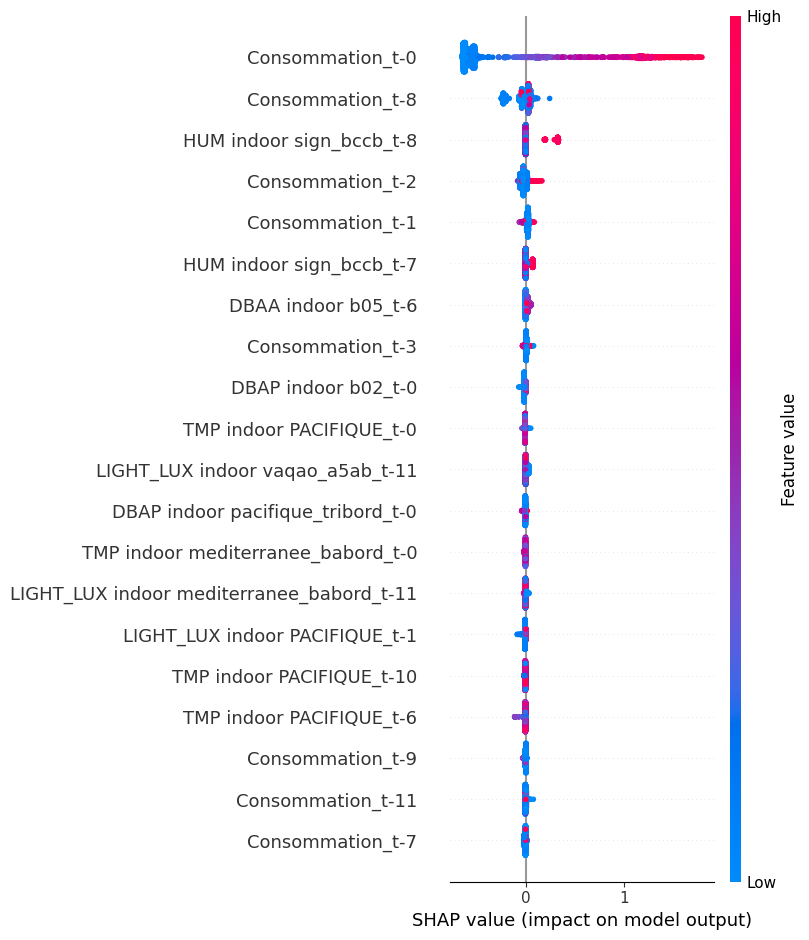

In [ ]:
shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, max_display=20, show=True)
